In [ ]:
# --- SETUP: run this first in any new notebook ---
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt

import pandas as pd

DATA_PATH = '/content/drive/MyDrive/data-projects/esg-data/'

esg = pd.read_csv(DATA_PATH + 'ESGData.csv')
country_info = pd.read_csv(DATA_PATH + 'ESGCountry.csv')
gdp_data = pd.read_csv(DATA_PATH + 'GDP by Country.csv', skiprows=4)

energy_mix = pd.read_csv(DATA_PATH + 'World Energy Consumption.csv')

real_countries = country_info[country_info["Region"].notna()]["Country Code"]
year_columns = [str(y) for y in range(1990, 2015)]

print("Setup complete. Data loaded:", esg.shape, country_info.shape, gdp_data.shape, energy_mix.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Data loaded: (16013, 67) (239, 31) (264, 63) (22012, 129)


In [ ]:
consumption_df = pd.read_csv(DATA_PATH + 'consumption-co2-per-capita.csv')
consumption_df.columns

Index(['entity', 'code', 'year', 'consumption_emissions_per_capita'], dtype='object')

In [ ]:
co2 = esg[esg["Indicator Name"] == "CO2 emissions (metric tons per capita)"]
co2_countries = co2[co2["Country Code"].isin(real_countries)]

chile = co2[co2["Country Name"] == "Chile"]
gdp_row = esg[(esg["Country Name"] == "Chile") &
              (esg["Indicator Name"] == "GDP growth (annual %)")]

In [ ]:
chile_long = chile.melt(id_vars=["Country Name"], value_vars=year_columns,
                          var_name="Year", value_name="production_co2_per_capita")

In [ ]:
gdp_long = gdp_row.melt(id_vars=["Country Name"], value_vars=year_columns,
                          var_name="Year", value_name="GDP_growth")

In [ ]:
combined = chile_long.merge(gdp_long, on=["Country Name", "Year"])
combined.head()

,Country Name,Year,production_co2_per_capita,GDP_growth
0,Chile,1990,2.509653,3.333565
1,Chile,1991,2.321076,7.804392
2,Chile,1992,2.367010,11.166708
3,Chile,1993,2.483158,6.588784
4,Chile,1994,2.689742,5.030198


In [ ]:
chile_consumption = consumption_df[consumption_df["entity"] == "Chile"]

chile_consumption = chile_consumption.rename(columns={
    "year": "Year",
    "consumption_emissions_per_capita": "consumption_co2_per_capita"
})
chile_consumption["Year"] = chile_consumption["Year"].astype(str)
chile_consumption.head()

,entity,code,Year,consumption_co2_per_capita
782,Chile,CHL,1990,2.409641
783,Chile,CHL,1991,2.297892
784,Chile,CHL,1992,2.442208
785,Chile,CHL,1993,2.560450
786,Chile,CHL,1994,2.718777


In [ ]:
final = combined.merge(chile_consumption[["Year", "consumption_co2_per_capita"]], on="Year", how="inner")
final.head()

,Country Name,Year,production_co2_per_capita,GDP_growth,consumption_co2_per_capita
0,Chile,1990,2.509653,3.333565,2.409641
1,Chile,1991,2.321076,7.804392,2.297892
2,Chile,1992,2.367010,11.166708,2.442208
3,Chile,1993,2.483158,6.588784,2.560450
4,Chile,1994,2.689742,5.030198,2.718777


In [ ]:
final["emissions_gap"] = final["consumption_co2_per_capita"] - final["production_co2_per_capita"]

In [ ]:
chile_gdp_size = gdp_data[(gdp_data["Country Name"] == "Chile") &
                            (gdp_data["Indicator Name"] == "GDP (current US$)")]

gdp_size_long = chile_gdp_size.melt(id_vars=["Country Name"], value_vars=year_columns,
                                      var_name="Year", value_name="GDP_size")

final = final.merge(gdp_size_long[["Year", "GDP_size"]], on="Year", how="inner")
final.head()

,Country Name,Year,production_co2_per_capita,GDP_growth,consumption_co2_per_capita,emissions_gap,GDP_size
0,Chile,1990,2.509653,3.333565,2.409641,-0.100012,3.311389e+10
1,Chile,1991,2.321076,7.804392,2.297892,-0.023184,3.783479e+10
2,Chile,1992,2.367010,11.166708,2.442208,0.075198,4.596433e+10
3,Chile,1993,2.483158,6.588784,2.560450,0.077292,4.929777e+10
4,Chile,1994,2.689742,5.030198,2.718777,0.029035,5.700843e+10


In [ ]:
print(final.shape)
print(final["Year"].min(), final["Year"].max())

(25, 7)
1990 2014


In [ ]:
final["emissions_gap"] = final["consumption_co2_per_capita"] - final["production_co2_per_capita"]
final[["Year", "production_co2_per_capita", "consumption_co2_per_capita", "emissions_gap"]]

,Year,production_co2_per_capita,consumption_co2_per_capita,emissions_gap
0,1990,2.509653,2.409641,-0.100012
1,1991,2.321076,2.297892,-0.023184
2,1992,2.367010,2.442208,0.075198
3,1993,2.483158,2.560450,0.077292
4,1994,2.689742,2.718777,0.029035
5,1995,2.902824,2.902829,0.000005
6,1996,3.324776,3.265630,-0.059147
7,1997,3.814010,3.732426,-0.081584
8,1998,3.848484,3.975465,0.126980
9,1999,4.056172,3.944112,-0.112060


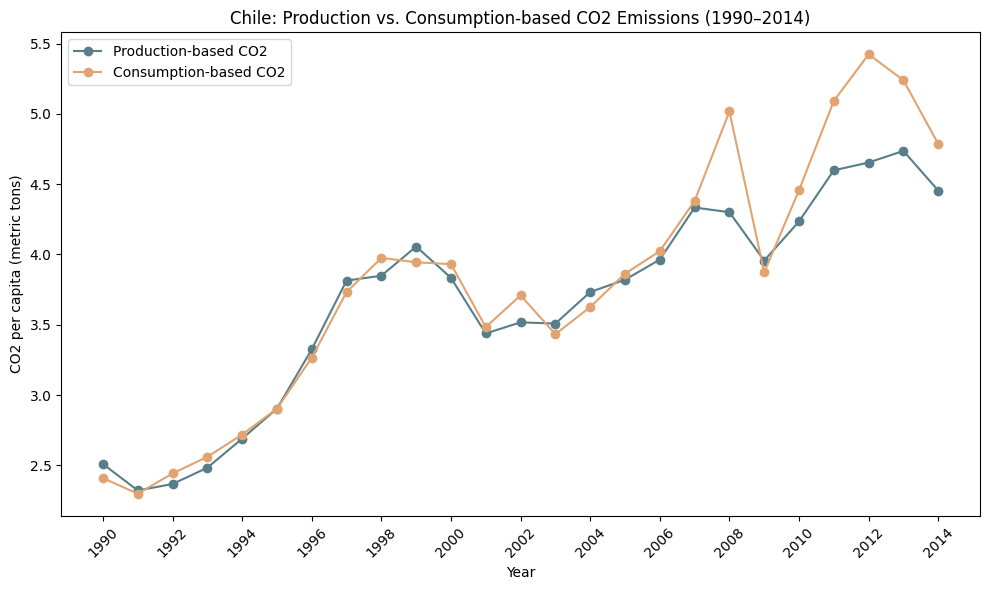

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(final["Year"], final["production_co2_per_capita"], color="#577E89", marker="o", label="Production-based CO2")
ax.plot(final["Year"], final["consumption_co2_per_capita"], color="#E1A36F", marker="o", label="Consumption-based CO2")

ax.set_xlabel("Year")
ax.set_ylabel("CO2 per capita (metric tons)")
ax.set_title("Chile: Production vs. Consumption-based CO2 Emissions (1990–2014)")
ax.legend()

# thin out x-axis labels so 25 years doesn't get crowded
ax.set_xticks(final["Year"][::2])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/production_vs_consumption_co2.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

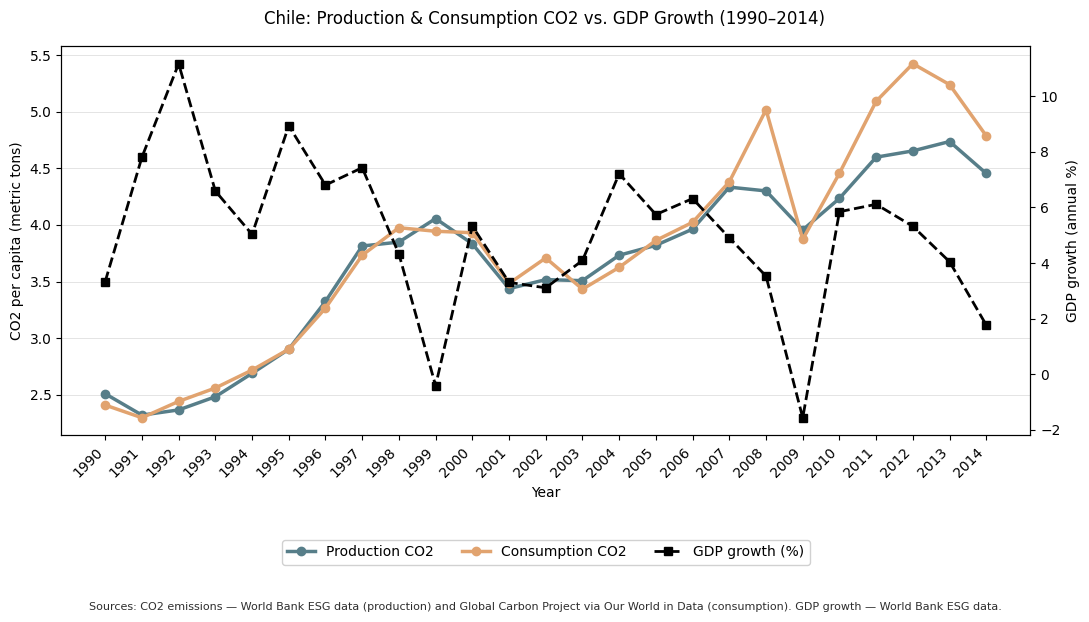

In [ ]:
fig, ax1 = plt.subplots(figsize=(11,6))

ax1.plot(final["Year"], final["production_co2_per_capita"], color="#577E89", marker="o", linewidth=2.5, label="Production CO2")
ax1.plot(final["Year"], final["consumption_co2_per_capita"], color="#E1A36F", marker="o", linewidth=2.5, label="Consumption CO2")
ax1.set_xlabel("Year")
ax1.set_ylabel("CO2 per capita (metric tons)")

ax1.set_xticks(final["Year"])
ax1.set_xticklabels(final["Year"], rotation=45, ha="right")

ax1.grid(axis="y", color="grey", alpha=0.25, linewidth=0.6)
ax1.set_axisbelow(True)

ax2 = ax1.twinx()
ax2.plot(final["Year"], final["GDP_growth"], color="black", marker="s", linestyle="--",
         linewidth=2, markersize=6, label="GDP growth (%)")
ax2.set_ylabel("GDP growth (annual %)", color="black")
ax2.tick_params(axis="y", labelcolor="black")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center",
           bbox_to_anchor=(0.5, -0.25), ncol=3, framealpha=0.9)

fig.suptitle("Chile: Production & Consumption CO2 vs. GDP Growth (1990–2014)")

fig.text(0.5, -0.02,
         "Sources: CO2 emissions — World Bank ESG data (production) and Global Carbon Project via Our World in Data (consumption). "
         "GDP growth — World Bank ESG data.",
         ha="center", fontsize=8, color="#2E2E2E")

plt.tight_layout()
plt.savefig('charts/co2_vs_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()

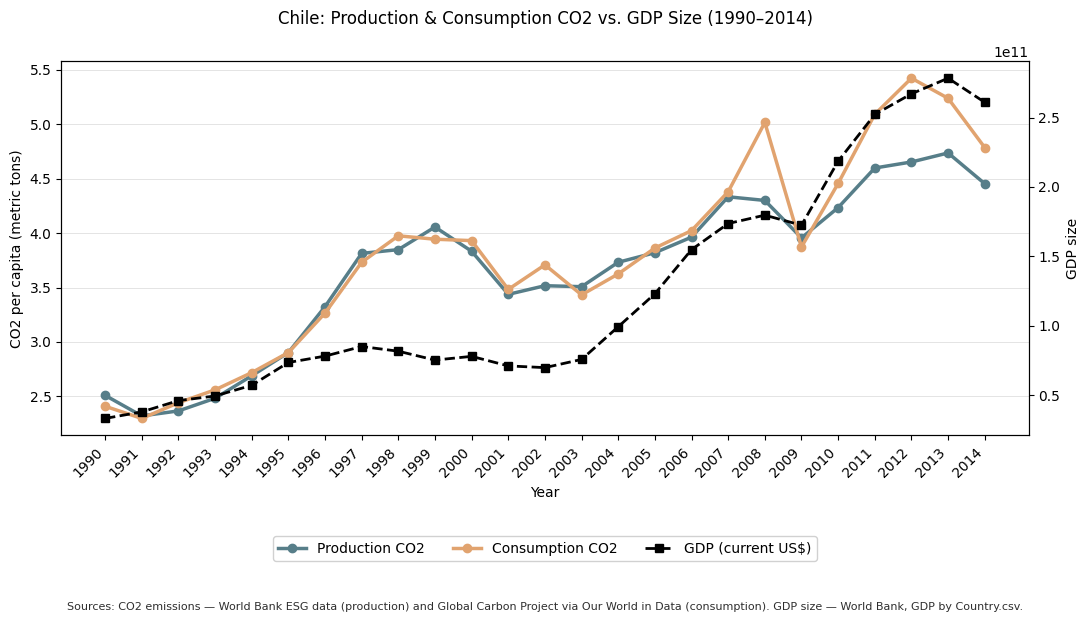

In [ ]:
fig, ax1 = plt.subplots(figsize=(11,6))

ax1.plot(final["Year"], final["production_co2_per_capita"], color="#577E89", marker="o", linewidth=2.5, label="Production CO2")
ax1.plot(final["Year"], final["consumption_co2_per_capita"], color="#E1A36F", marker="o", linewidth=2.5, label="Consumption CO2")
ax1.set_xlabel("Year")
ax1.set_ylabel("CO2 per capita (metric tons)")

ax1.set_xticks(final["Year"])
ax1.set_xticklabels(final["Year"], rotation=45, ha="right")

ax1.grid(axis="y", color="grey", alpha=0.25, linewidth=0.6)
ax1.set_axisbelow(True)

ax2 = ax1.twinx()
ax2.plot(final["Year"], final["GDP_size"], color="black", marker="s", linestyle="--",
         linewidth=2, markersize=6, label="GDP (current US$)")
ax2.set_ylabel("GDP size", color="black")
ax2.tick_params(axis="y", labelcolor="black")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center",
           bbox_to_anchor=(0.5, -0.25), ncol=3, framealpha=0.9)

fig.suptitle("Chile: Production & Consumption CO2 vs. GDP Size (1990–2014)")

fig.text(0.5, -0.02,
         "Sources: CO2 emissions — World Bank ESG data (production) and Global Carbon Project via Our World in Data (consumption). "
         "GDP size — World Bank, GDP by Country.csv.",
         ha="center", fontsize=8, color="#2E2E2E")

plt.tight_layout()
plt.savefig('charts/co2_vs_gdp_size.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
correlation_growth = final["production_co2_per_capita"].corr(final["GDP_growth"])
correlation_size = final["production_co2_per_capita"].corr(final["GDP_size"])
print(f"Correlation: CO2 vs GDP growth = {correlation_growth:.2f}")
print(f"Correlation: CO2 vs GDP size = {correlation_size:.2f}")

Correlation: CO2 vs GDP growth = -0.42
Correlation: CO2 vs GDP size = 0.85


In [ ]:
import numpy as np

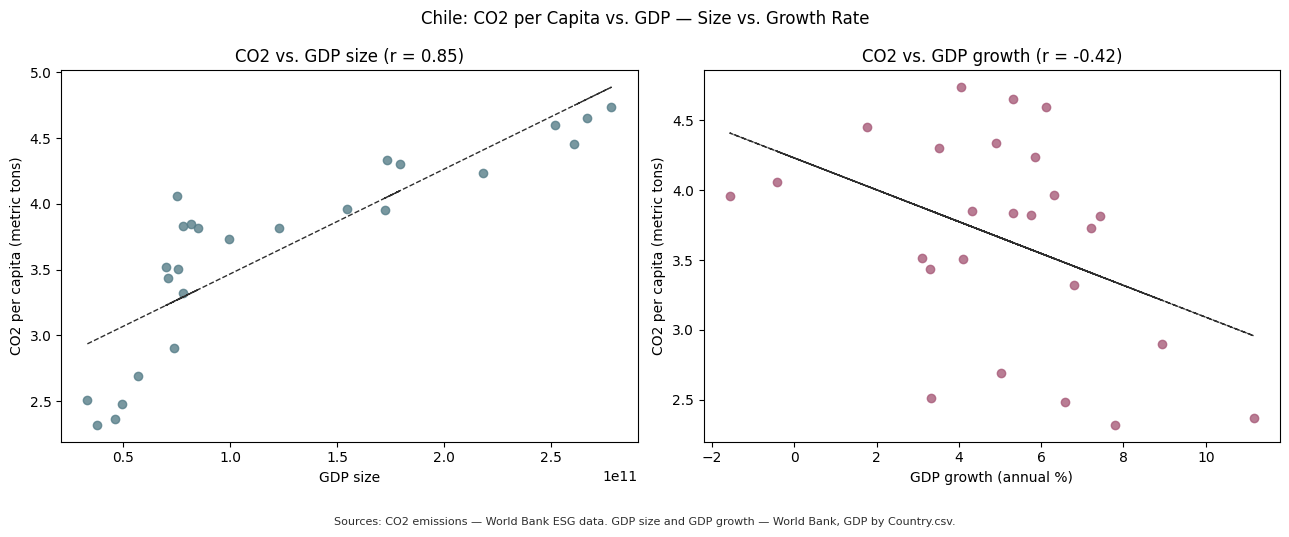

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].scatter(final["GDP_size"], final["production_co2_per_capita"], color="#577E89", alpha=0.8)
z = np.polyfit(final["GDP_size"], final["production_co2_per_capita"], 1)
axes[0].plot(final["GDP_size"], np.poly1d(z)(final["GDP_size"]), color="#2E2E2E", linestyle="--", linewidth=1)
axes[0].set_xlabel("GDP size")
axes[0].set_ylabel("CO2 per capita (metric tons)")
axes[0].set_title(f"CO2 vs. GDP size (r = {correlation_size:.2f})")

axes[1].scatter(final["GDP_growth"], final["production_co2_per_capita"], color="#A85C7A", alpha=0.8)
z2 = np.polyfit(final["GDP_growth"], final["production_co2_per_capita"], 1)
axes[1].plot(final["GDP_growth"], np.poly1d(z2)(final["GDP_growth"]), color="#2E2E2E", linestyle="--", linewidth=1)
axes[1].set_xlabel("GDP growth (annual %)")
axes[1].set_ylabel("CO2 per capita (metric tons)")
axes[1].set_title(f"CO2 vs. GDP growth (r = {correlation_growth:.2f})")

fig.suptitle("Chile: CO2 per Capita vs. GDP — Size vs. Growth Rate")
plt.tight_layout()

fig.text(0.5, -0.05,
         "Sources: CO2 emissions — World Bank ESG data. GDP size and GDP growth — World Bank, GDP by Country.csv.",
         ha="center", fontsize=8, color="#2E2E2E")
plt.tight_layout()

plt.savefig('charts/co2_vs_gdp_scatter.png', dpi=150, bbox_inches='tight')


plt.show()

In [ ]:
import os
os.makedirs('charts', exist_ok=True)